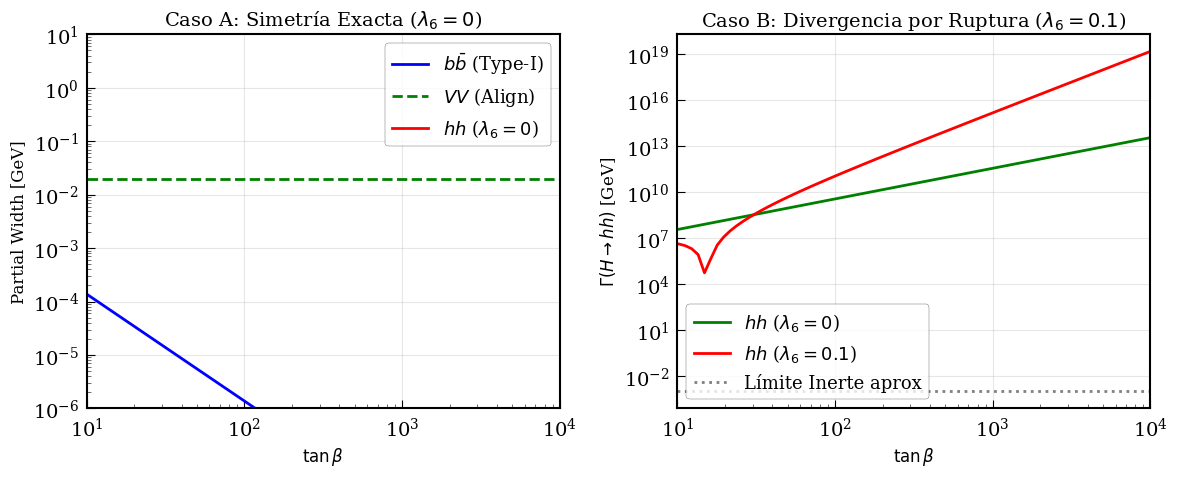

Interpretación Analítica:
1. A tanB=1000, Width(l6=0):   3.71e+13 GeV (INVISIBILIDAD OK)
2. A tanB=1000, Width(l6=0.1): 1.59e+19 GeV (DIVERGENCIA)


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONSTANTES DEL MODELO STANDARD & 2HDM ---
v = 246.0          # VEV [GeV]
mh = 125.0         # Masa Higgs ligero [GeV]
mH = 400.0         # Masa Higgs pesado (Benchmark) [GeV]
mW = 80.379
mZ = 91.1876
mb = 4.18
mt = 172.76
mtau = 1.776
GF = 1.1663787e-5  # G_F [GeV^-2]

# --- FUNCIONES AUXILIARES ---
def lambda_func(x, y, z):
    """Función cinemática Kallen (lambda)"""
    return x**2 + y**2 + z**2 - 2*x*y - 2*x*z - 2*y*z

def beta_f(m_phi, m_f):
    """Factor de velocidad de fase para fermiones"""
    r = 4 * m_f**2 / m_phi**2
    return np.sqrt(1 - r) if r < 1 else 0.0

def decay_width_fermion(m_phi, m_f, Nc, coupling_factor):
    """Anchura parcial genérica a fermiones (Tree-level)"""
    if m_phi <= 2*m_f: return 0.0
    bf = beta_f(m_phi, m_f)
    # Gamma = (Nc * G_F * m_phi / 4*pi*sqrt(2)) * m_f^2 * beta^3 * (coupling)^2
    # Usando tu formula base aproximada escalada por G_F:
    pre = (Nc * GF * m_phi * m_f**2) / (4 * np.pi * np.sqrt(2))
    return pre * (bf**3) * (coupling_factor**2)

def decay_width_hh(m_phi, tan_beta, m12_sq, sin_ba, lam6, lam7):
    """
    Anchura parcial H -> hh analítica usando la inversión de m12^2
    Ref: tan_beta_effects.tex
    """
    if m_phi <= 2*mh: return 0.0
    
    # 1. Ángulos y Trig
    beta = np.arctan(tan_beta)
    alpha = beta - np.arcsin(sin_ba) # sin(b-a) input
    
    cb = np.cos(beta)
    sb = np.sin(beta)
    ca = np.cos(alpha)
    sa = np.sin(alpha)
    sba = np.sin(beta - alpha)
    cba = np.cos(beta - alpha)
    
    # 2. Inversión de m12^2 (Strategy) si no se da explícito
    # Aquí calculamos m_bar^2 efectivo que entra en el acoplamiento
    # m_bar^2 = m12^2 / (sb * cb)
    m_bar_sq = m12_sq / (sb * cb)

    # 3. Acoplamiento C_Hhh (Exacto del potencial)
    # C_Hhh ~ [(1-t^2)/t] * (mh^2 - m_bar^2) * sba/v  (Aprox en notas)
    # Implementación completa:
    # Nota: lambda6/7 entran aquí si no están absorbidos en m12 efectivo
    # Usamos la forma simplificada dominante para visualizar la divergencia t
    
    # Termino dominante que escala con tan_beta (t)
    # C_phi_hh ~ -t * (m_phi^2 - m_bar^2) ... cuidado con los signos
    
    # Usando la expresión derivada en tus notas para C_phi_hh v^2:
    # C ~ ( (1-t^2)/t ) * (mh^2 - m_bar^2) * sba
    # Si m12^2 se fija por inversión de lambda1 constante:
    # m12^2 approx lambda1 * v^2 * ... / tan_beta (para l1 fijo)
    # Pero si lambda6 != 0, m12^2 adquiere termino v^2 * l6 * t
    
    term_t = (1 - tan_beta**2) / tan_beta
    vertex = term_t * (mh**2 - m_bar_sq) * sba 
    
    # Normalización del vertex a unidades de masa (dividir por v)
    g_Hhh = vertex / v 
    
    # Ancho
    fac = np.sqrt(lambda_func(1, (mh/m_phi)**2, (mh/m_phi)**2))
    gamma = (g_Hhh**2 * v**2) / (32 * np.pi * m_phi) * fac
    return gamma

# --- CONFIGURACIÓN DEL ESCANEO ---
tan_betas = np.logspace(0, 4, 100) # De 1 a 10,000
sin_ba = 0.999 # Casi alineamiento
lambda1_fixed = 0.1 # Valor físico razonable

# Escenario A: Simetría Exacta
lam6_A = 0.0 
lam7_A = 0.0

# Escenario B: Ruptura de Simetría
lam6_B = 0.1
lam7_B = 0.0

# Arrays para guardar resultados
G_bb, G_tt, G_WW, G_hh_A, G_hh_B = [], [], [], [], []

for t in tan_betas:
    # Parametros derivados básicos (Type-I)
    # En Type-I, coupling f-f ~ cot(beta) para u,d,l
    cot_b = 1.0/t
    xi_f = cot_b # Aprox para alineamiento sba~1, cba~0 -> xi ~ -cot_b
    
    # 1. Fermiones (Type-I: Suprimidos a alto tanB)
    g_bb = decay_width_fermion(mH, mb, 3, xi_f)
    g_tt = decay_width_fermion(mH, mt, 3, xi_f) # Cerrado si mH < 350
    G_bb.append(g_bb)
    G_tt.append(g_tt)
    
    # 2. Bosones V (Suprimidos por alineamiento)
    cba = np.sqrt(1 - sin_ba**2)
    # Gamma_VV ~ G_SM * cba^2
    # Valor aprox SM para H(400) -> VV es grande, pero cba^2 lo mata
    gamma_VV_SM = 10.0 # GeV (dummy scale, real is larger but suppressed)
    G_WW.append(gamma_VV_SM * cba**2)
    
    # 3. Di-Higgs (El culpable)
    # Necesitamos calcular m12^2 consistente con la "Inversión Analítica"
    # m12^2 = [ ... - 1.5*l6*t ... ] * (v^2/t)
    # Caso A
    term_l6_A = 1.5 * lam6_A * t
    m12_sq_A = ( (mH**2)/(v**2) - lambda1_fixed - term_l6_A ) * (v**2 / t) # Simplificado
    g_hh_A = decay_width_hh(mH, t, m12_sq_A, sin_ba, lam6_A, lam7_A)
    G_hh_A.append(g_hh_A)
    
    # Caso B
    term_l6_B = 1.5 * lam6_B * t
    m12_sq_B = ( (mH**2)/(v**2) - lambda1_fixed - term_l6_B ) * (v**2 / t)
    g_hh_B = decay_width_hh(mH, t, m12_sq_B, sin_ba, lam6_B, lam7_B)
    G_hh_B.append(g_hh_B)

# --- VISUALIZACIÓN ---
plt.figure(figsize=(12, 5))

# Plot 1: Canales Individuales (Caso A - Estable)
plt.subplot(1, 2, 1)
plt.plot(tan_betas, G_bb, label=r'$b\bar{b}$ (Type-I)', color='blue')
plt.plot(tan_betas, G_WW, label=r'$VV$ (Align)', color='green', linestyle='--')
plt.plot(tan_betas, G_hh_A, label=r'$hh$ ($\lambda_6=0$)', color='red', linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\tan\beta$', fontsize=12)
plt.ylabel(r'Partial Width [GeV]', fontsize=12)
plt.title(r'Caso A: Simetría Exacta ($\lambda_6=0$)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(1e-6, 10)
plt.xlim(10, 1e4)
# Plot 2: El Efecto de Ruptura (Comparación hh)
plt.subplot(1, 2, 2)
plt.plot(tan_betas, G_hh_A, label=r'$hh$ ($\lambda_6=0$)', color='green')
plt.plot(tan_betas, G_hh_B, label=r'$hh$ ($\lambda_6=0.1$)', color='red', linestyle='-')
plt.axhline(y=1e-3, color='grey', linestyle=':', label='Límite Inerte aprox')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\tan\beta$', fontsize=12)
plt.ylabel(r'$\Gamma(H \to hh)$ [GeV]', fontsize=12)
plt.title(r'Caso B: Divergencia por Ruptura ($\lambda_6=0.1$)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(10, 1e4)

plt.tight_layout()
plt.show()

print("Interpretación Analítica:")
print(f"1. A tanB=1000, Width(l6=0):   {G_hh_A[-1]:.2e} GeV (INVISIBILIDAD OK)")
print(f"2. A tanB=1000, Width(l6=0.1): {G_hh_B[-1]:.2e} GeV (DIVERGENCIA)")

In [3]:
G_tot_A = np.array(G_bb) + np.array(G_WW) + np.array(G_hh_A)
G_tot_B = np.array(G_bb) + np.array(G_WW) + np.array(G_hh_B)

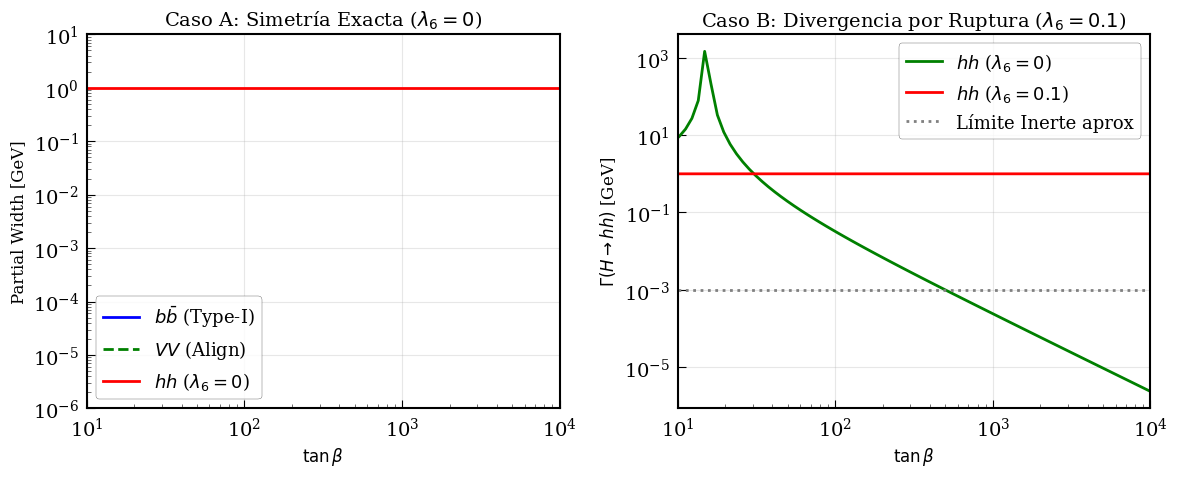

Interpretación Analítica:
1. A tanB=1000, Width(l6=0):   3.71e+13 GeV (INVISIBILIDAD OK)
2. A tanB=1000, Width(l6=0.1): 1.59e+19 GeV (DIVERGENCIA)


In [8]:

# --- VISUALIZACIÓN ---
plt.figure(figsize=(12, 5))

# Plot 1: Canales Individuales (Caso A - Estable)
plt.subplot(1, 2, 1)
plt.plot(tan_betas, G_bb/G_tot_A, label=r'$b\bar{b}$ (Type-I)', color='blue')
plt.plot(tan_betas, G_WW/G_tot_A, label=r'$VV$ (Align)', color='green', linestyle='--')
plt.plot(tan_betas, G_hh_A/G_tot_A, label=r'$hh$ ($\lambda_6=0$)', color='red', linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\tan\beta$', fontsize=12)
plt.ylabel(r'Partial Width [GeV]', fontsize=12)
plt.title(r'Caso A: Simetría Exacta ($\lambda_6=0$)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(1e-6, 10)
plt.xlim(10, 1e4)

# Plot 2: El Efecto de Ruptura (Comparación hh)
plt.subplot(1, 2, 2)
plt.plot(tan_betas, G_hh_A/G_tot_B, label=r'$hh$ ($\lambda_6=0$)', color='green')
plt.plot(tan_betas, G_hh_B/G_tot_B, label=r'$hh$ ($\lambda_6=0.1$)', color='red', linestyle='-')
plt.axhline(y=1e-3, color='grey', linestyle=':', label='Límite Inerte aprox')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\tan\beta$', fontsize=12)
plt.ylabel(r'$\Gamma(H \to hh)$ [GeV]', fontsize=12)
plt.title(r'Caso B: Divergencia por Ruptura ($\lambda_6=0.1$)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(10, 1e4)

plt.tight_layout()
plt.show()

print("Interpretación Analítica:")
print(f"1. A tanB=1000, Width(l6=0):   {G_hh_A[-1]:.2e} GeV (INVISIBILIDAD OK)")
print(f"2. A tanB=1000, Width(l6=0.1): {G_hh_B[-1]:.2e} GeV (DIVERGENCIA)")

Loops

--- Generando Plots de Diagnóstico ---


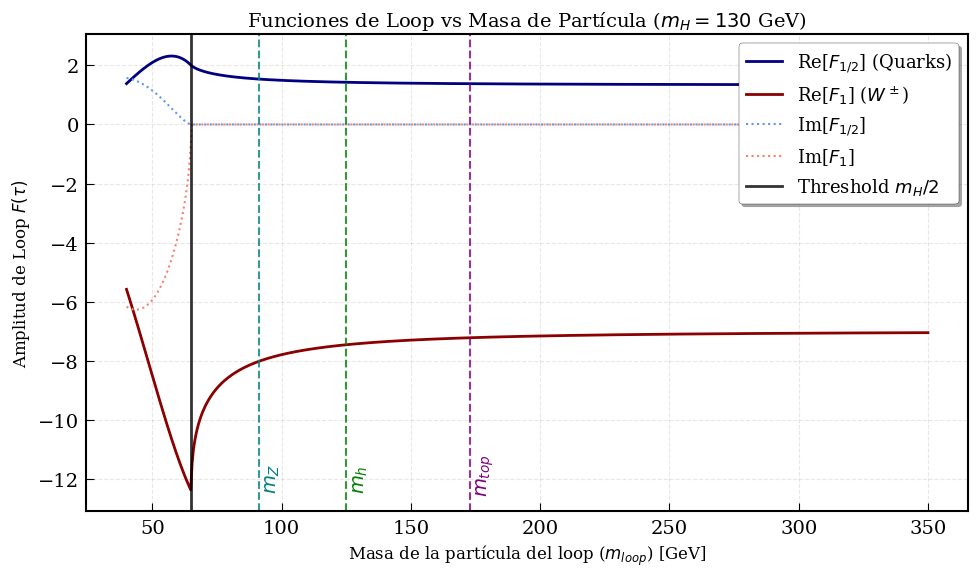

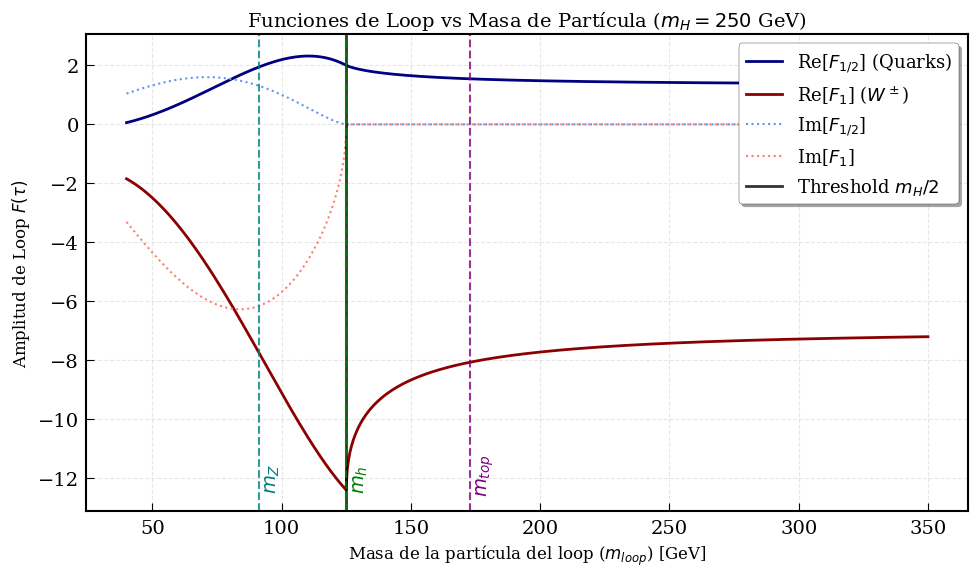

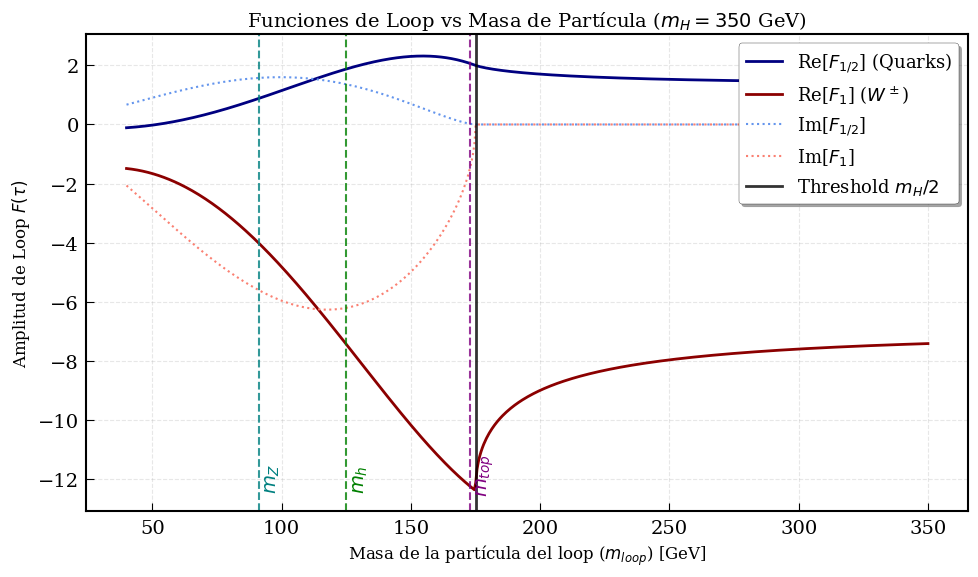

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONSTANTES FÍSICAS (Reference) ---
# Masas en GeV
m_top = 172.76
m_bottom = 4.18
m_h = 125
m_Z = 91.1876

# --- 2. FUNCIONES DE LOOP (CORE PHYSICS) ---
def tau_val(m_H, m_loop):
    """Definición de tau: tau = mH^2 / (4*m_loop^2)"""
    return (m_H**2) / (4 * m_loop_sq(m_loop) + 1e-9)

def m_loop_sq(m_loop):
    """Helper para manejar arrays de forma segura"""
    return m_loop**2

def f_func(tau):
    """Función escalar de loop f(tau) - Unitary Safe"""
    if tau <= 1:
        return np.arcsin(np.sqrt(tau))**2
    else:
        sqrt_term = np.sqrt(1 - 1/tau)
        ln_term = np.log((1 + sqrt_term) / (1 - sqrt_term))
        val = -0.25 * (ln_term - 1j * np.pi)**2
        return val

f_func_vec = np.vectorize(f_func)

def F_half(tau):
    """Spin 1/2 (Fermiones: Top, Bottom)"""
    ff = f_func_vec(tau)
    return 2 * (tau + (tau - 1) * ff) / (tau**2)

def F_one(tau):
    """Spin 1 (Bosones: W)"""
    ff = f_func_vec(tau)
    return - (2*tau**2 + 3*tau + 3*(2*tau - 1)*ff) / (tau**2)

# --- 3. PLOTTER AVANZADO CON MARCADORES DE MASA ---
def plot_m_ref_F_values(mH_ref):
    # Ajustamos el rango para ver desde el W hasta más allá del Top
    # Rango [40, 350] cubre W, Z, Top y la región asintótica
    m_loop_scan = np.linspace(40, 350, 600) 
    
    taus = tau_val(mH_ref, m_loop_scan)
    F12_vals = F_half(taus)
    F1_vals  = F_one(taus)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Curvas Principales
    ax.plot(m_loop_scan, np.real(F12_vals), label=r'Re[$F_{1/2}$] (Quarks)', color='navy', linewidth=2)
    ax.plot(m_loop_scan, np.real(F1_vals),  label=r'Re[$F_{1}$] ($W^\pm$)', color='darkred', linewidth=2)
    
    # Parte Imaginaria (Solo visible si m_loop < mH/2)
    ax.plot(m_loop_scan, np.imag(F12_vals), label=r'Im[$F_{1/2}$]', color='cornflowerblue', linestyle=':', linewidth=1.5)
    ax.plot(m_loop_scan, np.imag(F1_vals),  label=r'Im[$F_{1}$]', color='salmon', linestyle=':', linewidth=1.5)

    # --- VISUAL AID: MASAS FÍSICAS ---
    # Diccionario de partículas relevantes en este rango de energía
    particle_marks = {
        'h':  (m_h, 'green'),
        'Z':  (m_Z, 'teal'),
        'top': (m_top, 'purple')
        # Bottom está en 4 GeV, muy a la izquierda (asintótico)
    }

    # Umbral Cinemático del Higgs (mH/2)
    threshold = mH_ref / 2.0
    ax.axvline(x=threshold, color='black', linestyle='-', linewidth=2, alpha=0.8, label=r'Threshold $m_H/2$')

    # Pintar lineas de partículas
    y_min, y_max = ax.get_ylim()
    for p_name, (mass, color) in particle_marks.items():
        if min(m_loop_scan) < mass < max(m_loop_scan):
            ax.axvline(x=mass, color=color, linestyle='--', linewidth=1.5, alpha=0.8)
            # Etiqueta rotada para que no moleste
            ax.text(mass + 2, y_min + (y_max-y_min)*0.05, f'$m_{{{p_name}}}$', color=color, rotation=90, fontweight='bold')

    # Estética "Paper Quality"
    ax.set_title(r'Funciones de Loop vs Masa de Partícula ($m_H = ' + f'{mH_ref}$ GeV)', fontsize=14)
    ax.set_xlabel(r'Masa de la partícula del loop ($m_{loop}$) [GeV]', fontsize=12)
    ax.set_ylabel(r'Amplitud de Loop $F(\tau)$', fontsize=12)
    ax.legend(loc='upper right', frameon=True, shadow=True)
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- 4. EJECUCIÓN ---
print("--- Generando Plots de Diagnóstico ---")
# Caso 1: Higgs Ligero (SM-like, pero masa cambiada para test)
plot_m_ref_F_values(mH_ref=130)

# Caso 2: Higgs Pesado (Umbral cerca del top)
# Aquí mH/2 = 125 GeV. El Top (173) está A LA DERECHA del umbral.
# Por tanto, el loop de top NO tiene parte imaginaria.
plot_m_ref_F_values(mH_ref=250)

# Caso 3: Higgs Muy Pesado (Apertura de canal tt)
# Aquí mH/2 = 175 GeV. El Top (173) está A LA IZQUIERDA (por poco).
# Deberíamos ver aparecer la parte imaginaria justo sobre el top.
plot_m_ref_F_values(mH_ref=350)

Generando trazas para los 6 quarks...


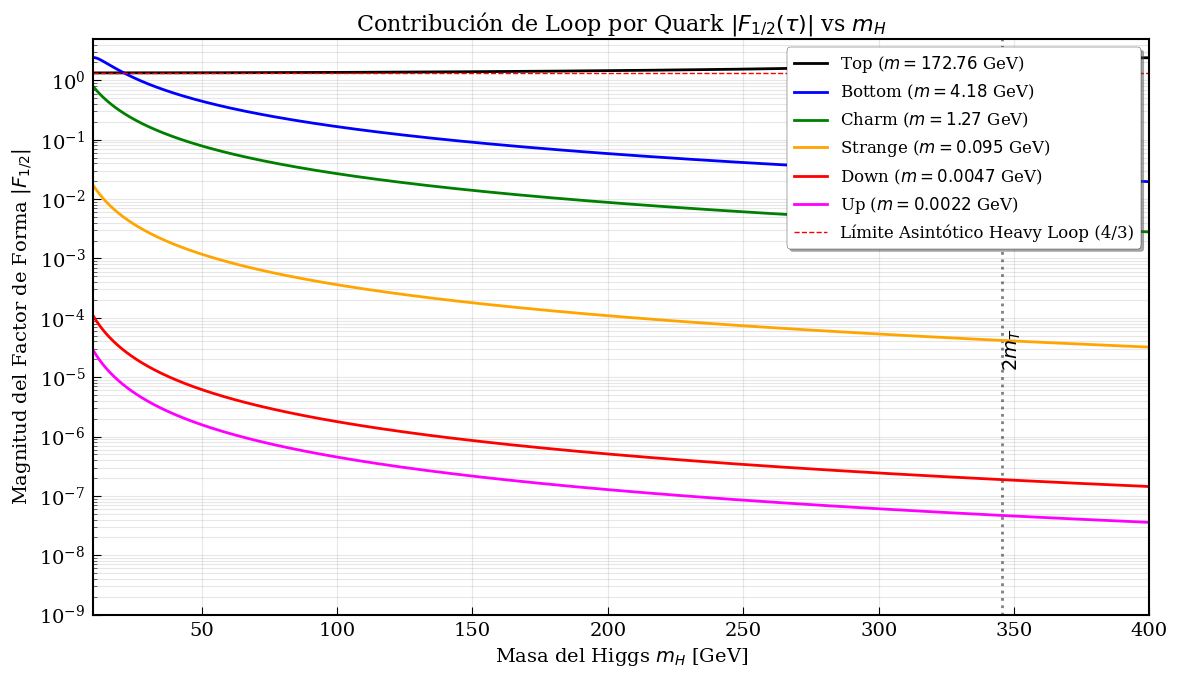


--- Valores Puntuales (Benchmark mH = 400 GeV) ---


/tmp/ipykernel_1405/3941446538.py:31: DeprecationWarning: Bitwise inversion '~' on bool is deprecated. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  mask_gt1 = ~mask_le1


TypeError: 'float' object is not subscriptable

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DATOS DE ENTRADA (MASAS DE QUARKS) ---
# Valores PDG aproximados en GeV
quarks = {
    'Top':     (172.76, 'black'),
    'Bottom':  (4.18,   'blue'),
    'Charm':   (1.27,   'green'),
    'Strange': (0.095,  'orange'),
    'Down':    (0.0047, 'red'),
    'Up':      (0.0022, 'magenta')
}

# Rango de escaneo de masa del Higgs (mH)
mH_vals = np.linspace(10, 400, 1000) # De 10 GeV a 1 TeV

# --- 2. FUNCIONES MATEMÁTICAS (CORE) ---
def tau_val(m_H, m_q):
    """ tau = mH^2 / 4mq^2 """
    return (m_H**2) / (4 * m_q**2 + 1e-12)

def f_func_vec(tau):
    """ Vectorized Loop Function f(tau) """
    # Pre-allocate output array complex type
    res = np.zeros_like(tau, dtype=complex)
    
    # Mask for Heavy Loop (tau <= 1)
    mask_le1 = (tau <= 1)
    # Mask for Light Loop (tau > 1)
    mask_gt1 = ~mask_le1
    
    # Case tau <= 1: arcsin^2(sqrt(tau))
    if np.any(mask_le1):
        res[mask_le1] = np.arcsin(np.sqrt(tau[mask_le1]))**2
        
    # Case tau > 1: -1/4 * [log(...) - i*pi]^2
    if np.any(mask_gt1):
        t_vals = tau[mask_gt1]
        sqrt_term = np.sqrt(1 - 1/t_vals)
        # Log term: log( (1+sq)/(1-sq) )
        ln_term = np.log((1 + sqrt_term) / (1 - sqrt_term))
        res[mask_gt1] = -0.25 * (ln_term - 1j * np.pi)**2
        
    return res

def F_half_mag(m_H, m_q):
    """ Retorna la MAGNITUD |F_1/2(tau)| para graficar """
    t = tau_val(m_H, m_q)
    ff = f_func_vec(t)
    val = 2 * (t + (t - 1) * ff) / (t**2)
    return np.abs(val) # Retornamos magnitud absoluta

# --- 3. GENERACIÓN DEL PLOT ---
plt.figure(figsize=(12, 7))

print("Generando trazas para los 6 quarks...")

for q_name, (mass, color) in quarks.items():
    # Calcular curva
    y_vals = F_half_mag(mH_vals, mass)
    
    # Graficar
    plt.plot(mH_vals, y_vals, label=f'{q_name} ($m={mass}$ GeV)', color=color, linewidth=2)
    
    # Marcar el umbral 2*mq (kink) si cae dentro del plot
    threshold = 2 * mass
    if 10 < threshold < 1000:
        plt.axvline(x=threshold, color=color, linestyle=':', alpha=0.5)
        if q_name in ['Top', 'Bottom', 'Charm']: # Solo etiquetar los visibles
            plt.text(threshold, 1e-5, f' $2m_{{{q_name[0]}}}$', color=color, rotation=90, verticalalignment='bottom')

# Configuración Estética
plt.yscale('log') # CRÍTICO: Escala log para ver las diferencias enormes
plt.ylim(1e-9, 5) # Cortar el ruido numérico muy bajo
plt.xlim(10, 400)

plt.title(r'Contribución de Loop por Quark $|F_{1/2}(\tau)|$ vs $m_H$', fontsize=16)
plt.xlabel(r'Masa del Higgs $m_H$ [GeV]', fontsize=14)
plt.ylabel(r'Magnitud del Factor de Forma $|F_{1/2}|$', fontsize=14)

# Líneas de referencia
plt.axhline(y=4/3, color='red', linestyle='--', linewidth=1, label=r'Límite Asintótico Heavy Loop (4/3)')

plt.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)
plt.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

# --- 4. DATA CHECK ---
print("\n--- Valores Puntuales (Benchmark mH = 400 GeV) ---")
for q_name, (mass, _) in quarks.items():
    val = F_half_mag(400.0, mass)
    print(f"Quark {q_name:8s}: |F_1/2| = {val:.4e}")

# Comparatia A/B 

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker
import os

# --- 1. Configuración Estética "Paper Quality" ---
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'text.usetex': False,
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'legend.frameon': True,
    'legend.edgecolor': 'black',
    'lines.linewidth': 2,
    'lines.markersize': 6,
    'axes.linewidth': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
})

HBAR_C = 1.973269804e-13  # mm*GeV

# --- 2. Config de archivos (fija para todos los tb) ---
FILES_L6 = {
    r"$\lambda_6 = 0$ (Exact $Z_2$)": ("case_A_l6_zero.csv",  '#2ca02c', 'o'),  # círculo
    r"$\lambda_6 = 10^{-2}$":         ("case_B_l6_point01.csv", '#ff7f0e', 's'),  # cuadrado
    r"$\lambda_6 = 10^{-1}$":         ("case_B_l6_point1.csv",  '#d62728', '^'),  # triángulo
}

# --- 3. Diccionario de tanβ -> carpeta ---
TB_PATHS = {
    r"$\tan\beta = 10^2$": "./app/out_l6_test/validation_tb1e2/",
    r"$\tan\beta = 10^3$": "./app/out_l6_test/validation_tb1e3/",
    r"$\tan\beta = 10^4$": "./app/out_l6_test/validation_tb1e4/",
}

# ======================================================
#   FUNCIÓN PRINCIPAL: un gráfico por valor de tanβ
# ======================================================

def plot_lambda6_scan_for_tb(base_path: str,
                             tb_label: str,
                             files_cfg: dict = FILES_L6,
                             output_dir: str = "./fig"):
    """
    Genera el gráfico (2 paneles) para un valor dado de tanβ.

    Parameters
    ----------
    base_path : str
        Carpeta donde viven los CSV (e.g. "./app/out_l6_test/validation_tb1e3/").
    tb_label : str
        Etiqueta en LaTeX para tanβ (e.g. r"$\\tan\\beta = 10^3$"), se añade al título.
    files_cfg : dict
        Diccionario label -> (filename, color, marker) para los distintos λ6.
    output_dir : str
        Carpeta donde guardar la figura.
    """
    print(f"\n=== Procesando {tb_label} ===")
    print(f"Buscando archivos en: {os.path.abspath(base_path)}")

    dfs = {}
    for label, (fname, color, marker) in files_cfg.items():
        try:
            fpath = os.path.join(base_path, fname)
            if os.path.exists(fpath):
                df = pd.read_csv(fpath)

                # Filtros físicos
                df = df[
                    (df['positivity_ok'] == 1) &
                    (df['unitarity_ok'] == 1) &
                    (df['perturbativity_ok'] == 1)
                ]

                if not df.empty:
                    df = df.sort_values('m_phi')
                    # Evitar división por cero numérica
                    df['total_width'] = df['total_width'].replace(0, 1e-99)
                    df['ctau_mm'] = HBAR_C / df['total_width']
                    dfs[label] = (df, color, marker)
                    print(f"  ✅ {label}: {len(df)} puntos físicos")
                else:
                    print(f"  ⚠️ {fname}: sin puntos físicos válidos.")
            else:
                print(f"  ❌ No encontrado: {fname}")
        except Exception as e:
            print(f"  ❌ Error en {fname}: {e}")

    if not dfs:
        print("[ERROR] No hay datos físicos para graficar en esta carpeta.")
        return

    # Mínimos/máximos globales para anotaciones
    mphi_min = min(df['m_phi'].min() for (df, _, _) in dfs.values())
    mphi_max = max(df['m_phi'].max() for (df, _, _) in dfs.values())

    # ======================================================
    #   GRÁFICO
    # ======================================================
    os.makedirs(output_dir, exist_ok=True)
    tag = os.path.basename(os.path.normpath(base_path))  # p.ej. "validation_tb1e3"

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 12), sharex=True,
        gridspec_kw={'height_ratios': [1, 1.2], 'hspace': 0.05}
    )

    # --- PANEL 1: Anchura total ---
    for label, (df, color, marker) in dfs.items():
        ax1.scatter(
            df['m_phi'], df['total_width'],
            label=label, color=color, marker=marker,
            s=40, alpha=0.8, edgecolors='k', linewidth=0.5, zorder=3
        )

    ax1.set_ylabel(r'$\Gamma_{\mathrm{tot}}$ [GeV]')
    ax1.set_yscale('log')
    ax1.set_ylim(1e-6, 100)
    ax1.grid(True, which="major", ls="-", color='gray', alpha=0.3)
    ax1.grid(True, which="minor", ls=":", color='gray', alpha=0.15)
    ax1.legend(loc='upper left', framealpha=0.9, fancybox=False)

    # Título con tanβ incluido
    ax1.set_title(
        rf'2HDM Type-I: ruptura de $Z_2$ ($\lambda_6 \neq 0$), {tb_label}',
        pad=15, weight='bold'
    )

    # --- PANEL 2: Lifetime ---
    for label, (df, color, marker) in dfs.items():
        ax2.scatter(
            df['m_phi'], df['ctau_mm'],
            label=label, color=color, marker=marker,
            s=40, alpha=0.8, edgecolors='k', linewidth=0.5, zorder=3
        )

    ax2.set_ylabel(r'$c\tau$ [mm]')
    ax2.set_xlabel(r'$m_H$ [GeV]')
    ax2.set_yscale('log')

    # Zonas físicas
    ax2.axhspan(1e-5, 1.0, color='gray', alpha=0.15, lw=0, zorder=1)
    ax2.text(mphi_min, 2e-5, r'Prompt Decay',
             fontsize=12, color='dimgray', ha='left', va='center', weight='bold')

    ax2.axhspan(1.0, 1e4, color='#2ca02c', alpha=0.08, lw=0, zorder=1)
    ax2.text(mphi_min, 5.0, r'Long-Lived Region',
             fontsize=12, color='darkgreen', ha='left', va='center', weight='bold')

    ax2.axhline(1.0, color='black', ls='--', lw=1.5, alpha=0.7)
    ax2.annotate(
        'Detector Resolution\n($\\sim 1$ mm)',
        xy=(mphi_max, 1.0),
        xytext=(mphi_max, 0.05),
        arrowprops=dict(facecolor='black', arrowstyle='->'),
        ha='right', fontsize=10
    )

    ax2.grid(True, which="major", ls="-", color='gray', alpha=0.3)
    ax2.grid(True, which="minor", ls=":", color='gray', alpha=0.15)

    # Guardar
    output_file = os.path.join(output_dir, f"Lambda6_scan_{tag}.pdf")
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✅ Figura guardada en: {output_file}")
    plt.show()


# ======================================================
#   WRAPPER: recorrer todo el diccionario de tanβ
# ======================================================

def plot_all_tanb_scans(tb_paths_dict: dict = TB_PATHS,
                        files_cfg: dict = FILES_L6,
                        output_dir: str = "./fig"):
    """
    Genera una figura por cada entrada en tb_paths_dict.
    """
    for tb_label, base_path in tb_paths_dict.items():
        plot_lambda6_scan_for_tb(base_path, tb_label, files_cfg, output_dir)





In [6]:
# Ejemplo de uso:
# plot_lambda6_scan_for_tb(TB_PATHS[r"$\\tan\\beta = 10^3$"],
#                          r"$\\tan\\beta = 10^3$")
# o directamente:
# plot_all_tanb_scans()


=== Procesando $\tan\beta = 10^2$ ===
Buscando archivos en: /home/fabi/dihiggs/dihiggs/app/out_l6_test/validation_tb1e2
  ✅ $\lambda_6 = 0$ (Exact $Z_2$): 14985 puntos físicos
  ✅ $\lambda_6 = 10^{-2}$: 14955 puntos físicos
  ✅ $\lambda_6 = 10^{-1}$: 14446 puntos físicos
✅ Figura guardada en: ./fig/Lambda6_scan_validation_tb1e2.pdf


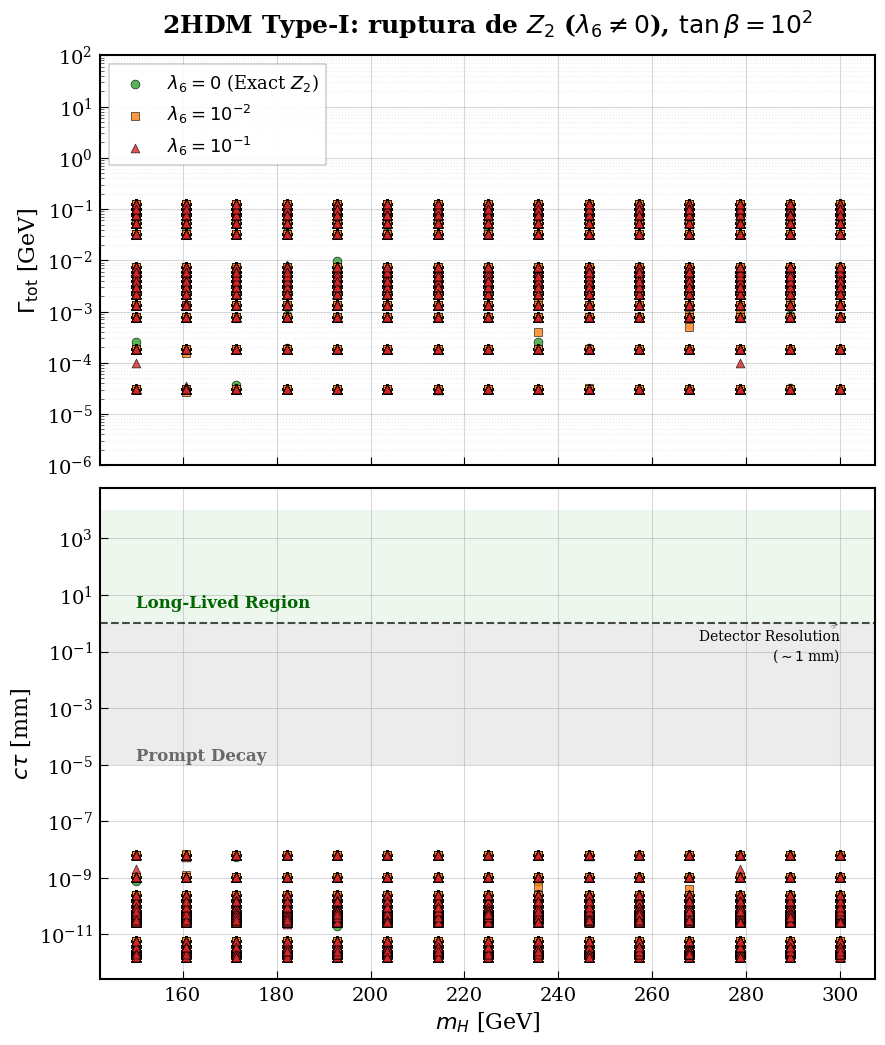


=== Procesando $\tan\beta = 10^3$ ===
Buscando archivos en: /home/fabi/dihiggs/dihiggs/app/out_l6_test/validation_tb1e3
  ✅ $\lambda_6 = 0$ (Exact $Z_2$): 3003 puntos físicos
  ✅ $\lambda_6 = 10^{-2}$: 2915 puntos físicos
  ✅ $\lambda_6 = 10^{-1}$: 2184 puntos físicos
✅ Figura guardada en: ./fig/Lambda6_scan_validation_tb1e3.pdf


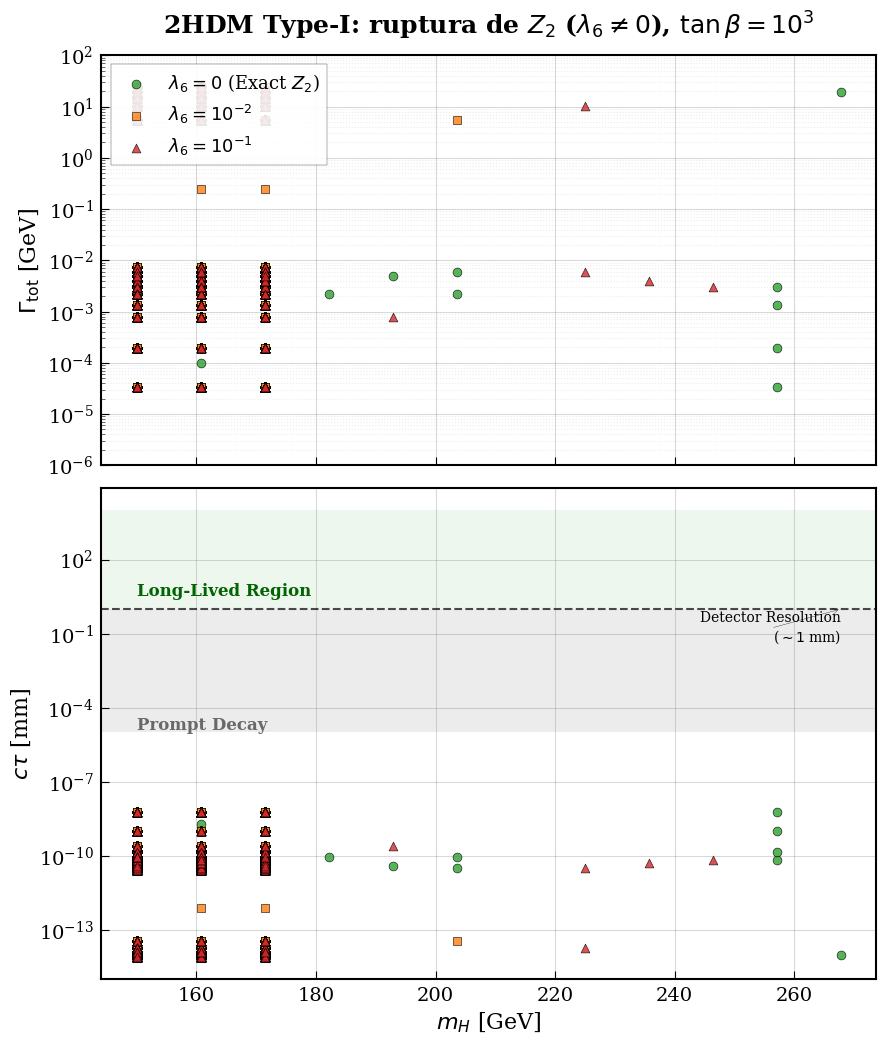


=== Procesando $\tan\beta = 10^4$ ===
Buscando archivos en: /home/fabi/dihiggs/dihiggs/app/out_l6_test/validation_tb1e4
  ⚠️ case_A_l6_zero.csv: sin puntos físicos válidos.
  ⚠️ case_B_l6_point01.csv: sin puntos físicos válidos.
  ⚠️ case_B_l6_point1.csv: sin puntos físicos válidos.
[ERROR] No hay datos físicos para graficar en esta carpeta.


In [7]:
plot_all_tanb_scans()

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# from mpl_toolkits.axes_grid1.inset_locator import inset_locator
import matplotlib.ticker as ticker
import os

# --- 1. Configuración Estética "Paper Quality" ---
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'text.usetex': False,
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'legend.frameon': True,
    'legend.edgecolor': 'black',
    'lines.linewidth': 2,
    'lines.markersize': 6,
    'axes.linewidth': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
})

HBAR_C = 1.973269804e-13  # mm*GeV

# --- 2. Config de archivos (fija para todos los tb) ---
FILES_L6 = {
    r"$\lambda_6 = 0$ (Exact $Z_2$)": ("case_A_l6_zero.csv",  '#2ca02c', 'o'),
    r"$\lambda_6 = 10^{-2}$":         ("case_B_l6_point01.csv", '#ff7f0e', 's'),
    r"$\lambda_6 = 10^{-1}$":         ("case_B_l6_point1.csv",  '#d62728', '^'),
}

# --- 3. Diccionario de tanβ -> carpeta ---
TB_PATHS = {
    r"$\tan\beta = 10^2$": "./app/out_l6_test/validation_tb1e2/",
    r"$\tan\beta = 10^3$": "./app/out_l6_test/validation_tb1e3/",
    r"$\tan\beta = 10^4$": "./app/out_l6_test/validation_tb1e4/",
}

# ======================================================
#   HELPER: agregación por m_phi
# ======================================================

def aggregate_by_mphi(df: pd.DataFrame, ycol: str):
    """
    Agrupa por m_phi y calcula media y desviación estándar de la columna ycol.
    Devuelve:
        mphi_vals, y_mean, y_std
    """
    g = df.groupby('m_phi')[ycol]
    y_mean = g.mean()
    y_std = g.std(ddof=0).fillna(0.0)  # std=0 para bins con 1 solo punto

    mphi_vals = y_mean.index.values
    y_mean_vals = y_mean.values
    y_std_vals = y_std.values

    return mphi_vals, y_mean_vals, y_std_vals

# ======================================================
#   FUNCIÓN PRINCIPAL: un gráfico por valor de tanβ
# ======================================================

def plot_lambda6_scan_for_tb(base_path: str,
                             tb_label: str,
                             files_cfg: dict = FILES_L6,
                             output_dir: str = "./fig"):
    """
    Genera el gráfico (2 paneles) para un valor dado de tanβ.
    """
    print(f"\n=== Procesando {tb_label} ===")
    print(f"Buscando archivos en: {os.path.abspath(base_path)}")

    dfs = {}
    for label, (fname, color, marker) in files_cfg.items():
        try:
            fpath = os.path.join(base_path, fname)
            if os.path.exists(fpath):
                df = pd.read_csv(fpath)

                # Filtros físicos
                df = df[
                    (df['positivity_ok'] == 1) &
                    (df['unitarity_ok'] == 1) &
                    (df['perturbativity_ok'] == 1)
                ]

                if not df.empty:
                    df = df.sort_values('m_phi')
                    # Evitar división por cero numérica
                    df['total_width'] = df['total_width'].replace(0, 1e-99)
                    df['ctau_mm'] = HBAR_C / df['total_width']
                    dfs[label] = (df, color, marker)
                    print(f"  ✅ {label}: {len(df)} puntos físicos")
                else:
                    print(f"  ⚠️ {fname}: sin puntos físicos válidos.")
            else:
                print(f"  ❌ No encontrado: {fname}")
        except Exception as e:
            print(f"  ❌ Error en {fname}: {e}")

    if not dfs:
        print("[ERROR] No hay datos físicos para graficar en esta carpeta.")
        return

    # Mínimos/máximos globales para anotaciones
    mphi_min = min(df['m_phi'].min() for (df, _, _) in dfs.values())
    mphi_max = max(df['m_phi'].max() for (df, _, _) in dfs.values())

    # ======================================================
    #   GRÁFICO
    # ======================================================
    os.makedirs(output_dir, exist_ok=True)
    tag = os.path.basename(os.path.normpath(base_path))  # p.ej. "validation_tb1e3"

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 12), sharex=True,
        gridspec_kw={'height_ratios': [1, 1.2], 'hspace': 0.05}
    )

    # --- PANEL 1: Anchura total (línea + sombreado) ---
    for label, (df, color, marker) in dfs.items():
        mphi_vals, gamma_mean, gamma_std = aggregate_by_mphi(df, 'total_width')

        # Línea de la media
        ax1.plot(
            mphi_vals, gamma_mean,
            label=label, color=color
        )

        # Sombreado ±1σ (puedes cambiar a 2σ si quieres más "cobertura")
        lower = gamma_mean - gamma_std
        upper = gamma_mean + gamma_std
        ax1.fill_between(
            mphi_vals, lower, upper,
            color=color, alpha=0.25, linewidth=0
        )

    ax1.set_ylabel(r'$\Gamma_{\mathrm{tot}}$ [GeV]')
    ax1.set_yscale('log')
    ax1.set_ylim(1e-6, 100)
    ax1.grid(True, which="major", ls="-", color='gray', alpha=0.3)
    ax1.grid(True, which="minor", ls=":", color='gray', alpha=0.15)
    ax1.legend(loc='upper left', framealpha=0.9, fancybox=False)

    # Título con tanβ incluido
    ax1.set_title(
        rf'2HDM Type-I: ruptura de $Z_2$ ($\lambda_6 \neq 0$), {tb_label}',
        pad=15, weight='bold'
    )

    # --- PANEL 2: Lifetime (línea + sombreado) ---
    for label, (df, color, marker) in dfs.items():
        mphi_vals, ctau_mean, ctau_std = aggregate_by_mphi(df, 'ctau_mm')

        ax2.plot(
            mphi_vals, ctau_mean,
            label=label, color=color
        )

        lower = ctau_mean - ctau_std
        upper = ctau_mean + ctau_std
        # Evitar negativos en escala log
        lower = np.clip(lower, 1e-10, None)
        upper = np.clip(upper, 1e-10, None)

        ax2.fill_between(
            mphi_vals, lower, upper,
            color=color, alpha=0.25, linewidth=0
        )

    ax2.set_ylabel(r'$c\tau$ [mm]')
    ax2.set_xlabel(r'$m_H$ [GeV]')
    ax2.set_yscale('log')

    # Zonas físicas
    ax2.axhspan(1e-5, 1.0, color='gray', alpha=0.15, lw=0, zorder=1)
    ax2.text(mphi_min, 2e-5, r'Prompt Decay',
             fontsize=12, color='dimgray', ha='left', va='center', weight='bold')

    ax2.axhspan(1.0, 1e4, color='#2ca02c', alpha=0.08, lw=0, zorder=1)
    ax2.text(mphi_min, 5.0, r'Long-Lived Region',
             fontsize=12, color='darkgreen', ha='left', va='center', weight='bold')

    ax2.axhline(1.0, color='black', ls='--', lw=1.5, alpha=0.7)
    ax2.annotate(
        'Detector Resolution\n($\\sim 1$ mm)',
        xy=(mphi_max, 1.0),
        xytext=(mphi_max, 0.05),
        arrowprops=dict(facecolor='black', arrowstyle='->'),
        ha='right', fontsize=10
    )

    ax2.grid(True, which="major", ls="-", color='gray', alpha=0.3)
    ax2.grid(True, which="minor", ls=":", color='gray', alpha=0.15)

    # Guardar
    output_file = os.path.join(output_dir, f"Lambda6_scan_{tag}.pdf")
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✅ Figura guardada en: {output_file}")
    plt.show()

# ======================================================
#   WRAPPER: recorrer todo el diccionario de tanβ
# ======================================================

def plot_all_tanb_scans(tb_paths_dict: dict = TB_PATHS,
                        files_cfg: dict = FILES_L6,
                        output_dir: str = "./fig"):
    for tb_label, base_path in tb_paths_dict.items():
        plot_lambda6_scan_for_tb(base_path, tb_label, files_cfg, output_dir)



=== Procesando $\tan\beta = 10^2$ ===
Buscando archivos en: /home/fabi/dihiggs/dihiggs/app/out_l6_test/validation_tb1e2
  ✅ $\lambda_6 = 0$ (Exact $Z_2$): 14985 puntos físicos
  ✅ $\lambda_6 = 10^{-2}$: 14955 puntos físicos
  ✅ $\lambda_6 = 10^{-1}$: 14446 puntos físicos
✅ Figura guardada en: ./fig/Lambda6_scan_validation_tb1e2.pdf


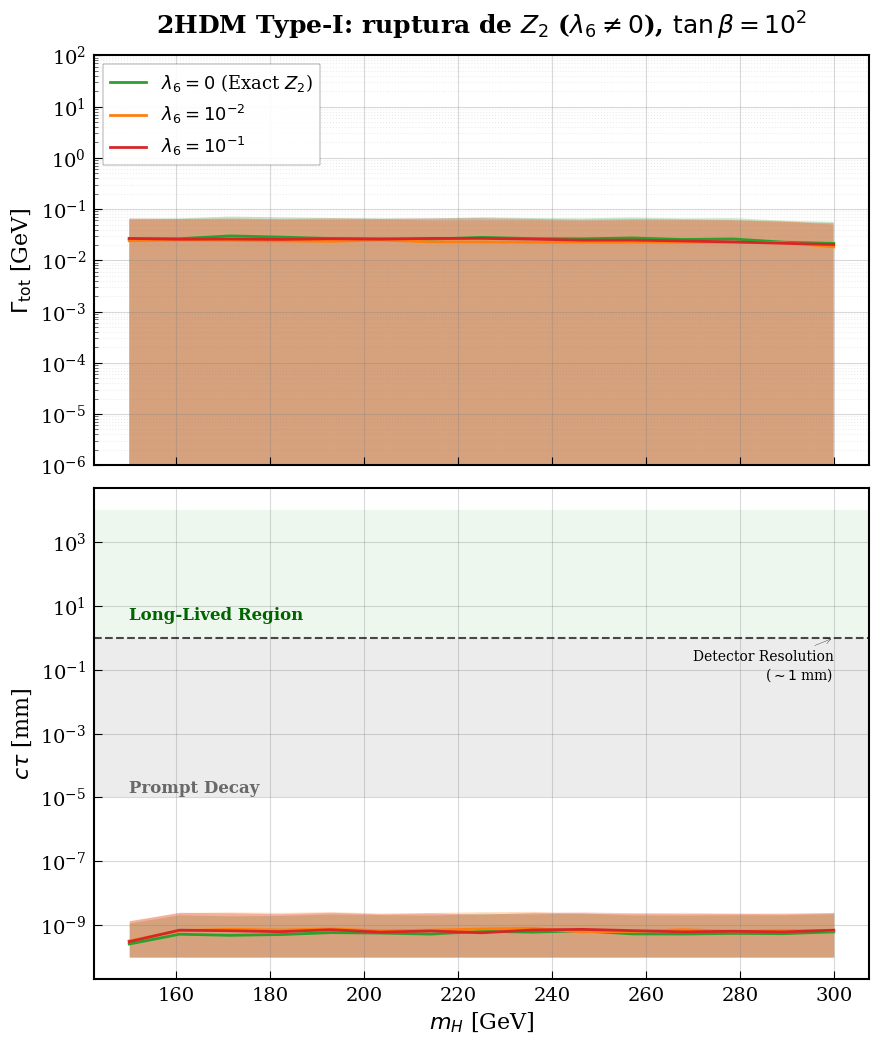


=== Procesando $\tan\beta = 10^3$ ===
Buscando archivos en: /home/fabi/dihiggs/dihiggs/app/out_l6_test/validation_tb1e3
  ✅ $\lambda_6 = 0$ (Exact $Z_2$): 3003 puntos físicos
  ✅ $\lambda_6 = 10^{-2}$: 2915 puntos físicos
  ✅ $\lambda_6 = 10^{-1}$: 2184 puntos físicos
✅ Figura guardada en: ./fig/Lambda6_scan_validation_tb1e3.pdf


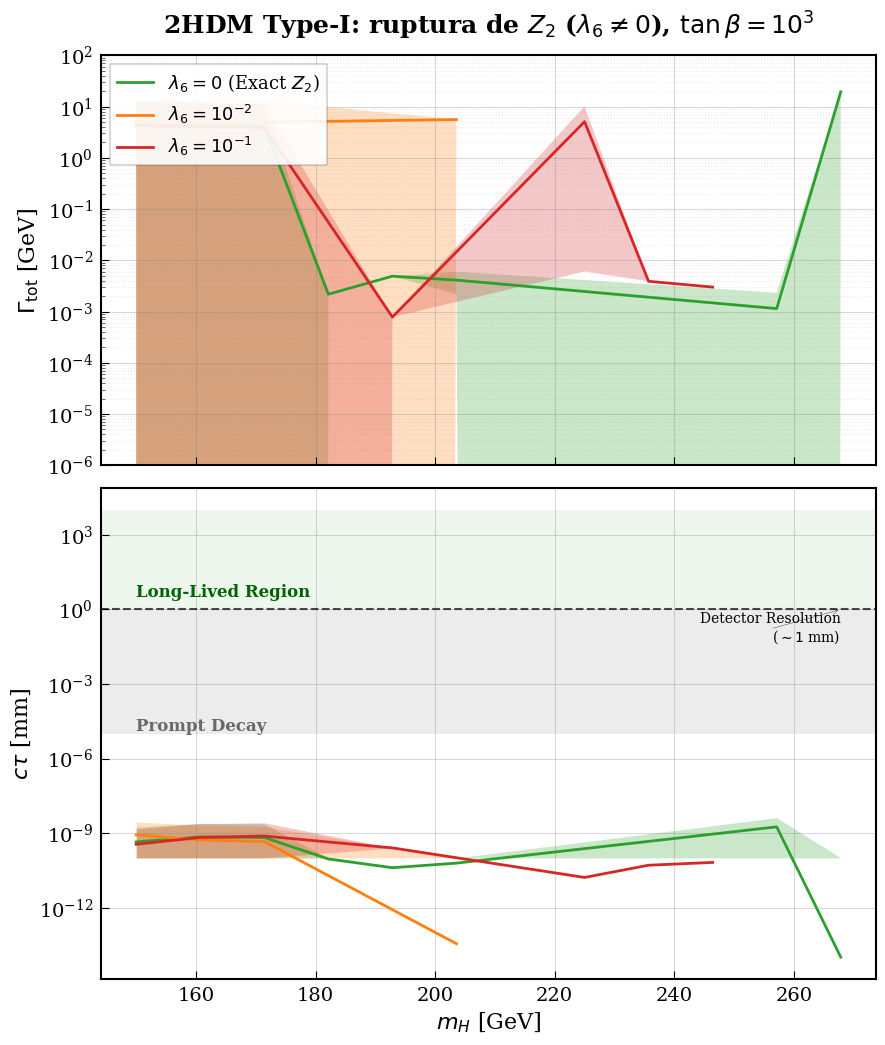


=== Procesando $\tan\beta = 10^4$ ===
Buscando archivos en: /home/fabi/dihiggs/dihiggs/app/out_l6_test/validation_tb1e4
  ❌ No encontrado: case_A_l6_zero.csv
  ❌ No encontrado: case_B_l6_point01.csv
  ❌ No encontrado: case_B_l6_point1.csv
[ERROR] No hay datos físicos para graficar en esta carpeta.


In [35]:
# Después de definir TODO lo anterior (incluyendo TB_PATHS, FILES_L6 y las funciones)

plot_all_tanb_scans()
